# Plant Disease Classification - Training Phase
In this section, we import the necessary libraries and set up the data generators for training and validation.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import json
import pickle
from tensorflow.keras import layers, models

# Paths and Parameters
DATASET_PATH = r"C:\Users\Kanishka Kumar\OneDrive\Desktop\plant-diseases-cnn\Dataset"
img_size = 128
batch = 32

# Data Augmentation
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

# Training Set
train = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(img_size, img_size),
    batch_size=batch,
    subset="training",
)

# Validation Set
val = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(img_size, img_size),
    batch_size=batch,
    subset="validation",
)

# Save class indices for testing later
json.dump(train.class_indices, open("class_indices.json", "w"))

Found 130345 images belonging to 40 classes.
Found 32571 images belonging to 40 classes.


In [2]:
from tensorflow.keras.applications import MobileNetV2

# Load Pre-trained Base Model
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Building the Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary() # Isse GitHub par model ka structure dikhega

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,200 (9.90 MB)

 Trainable params: 338,216 (1.29 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [3]:
# Start Training
history = model.fit(train, validation_data=val, epochs=25)

# Save History and Model
pickle.dump(history.history, open("history.pkl", "wb"))
model.save("plant_disease_model.keras")
print("Model and history saved successfully!")

Epoch 1/25
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 833s 204ms/step - accuracy: 0.9128 - loss: 0.2999 - val_accuracy: 0.8207 - val_loss: 1.5473
Epoch 2/25
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 862s 212ms/step - accuracy: 0.9401 - loss: 0.1949 - val_accuracy: 0.8371 - val_loss: 1.1655
Epoch 3/25
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 874s 215ms/step - accuracy: 0.9444 - loss: 0.1816 - val_accuracy: 0.8370 - val_loss: 1.5426
Epoch 4/25
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 892s 219ms/step - accuracy: 0.9485 - loss: 0.1727 - val_accuracy: 0.8394 - val_loss: 2.0311
Epoch 5/25
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 822s 202ms/step - accuracy: 0.9502 - loss: 0.1652 - val_accuracy: 0.8318 - val_loss: 1.9739
Epoch 6/25
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 840s 206ms/step - accuracy: 0.9525 - loss: 0.1613 - val_accuracy: 0.8295 - val_loss: 2.4036
Epoch 7/25
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 862s 212ms/step - accuracy: 0.9523 - loss: 0.1612 - val_accuracy: 0.8324 - val_loss: 2.2936
Epoch 8/25
4074/4074 ━━━━━━━━━━━━━━━━━━━━ 807s 198ms/step - ac

# Visualizing Model Performance

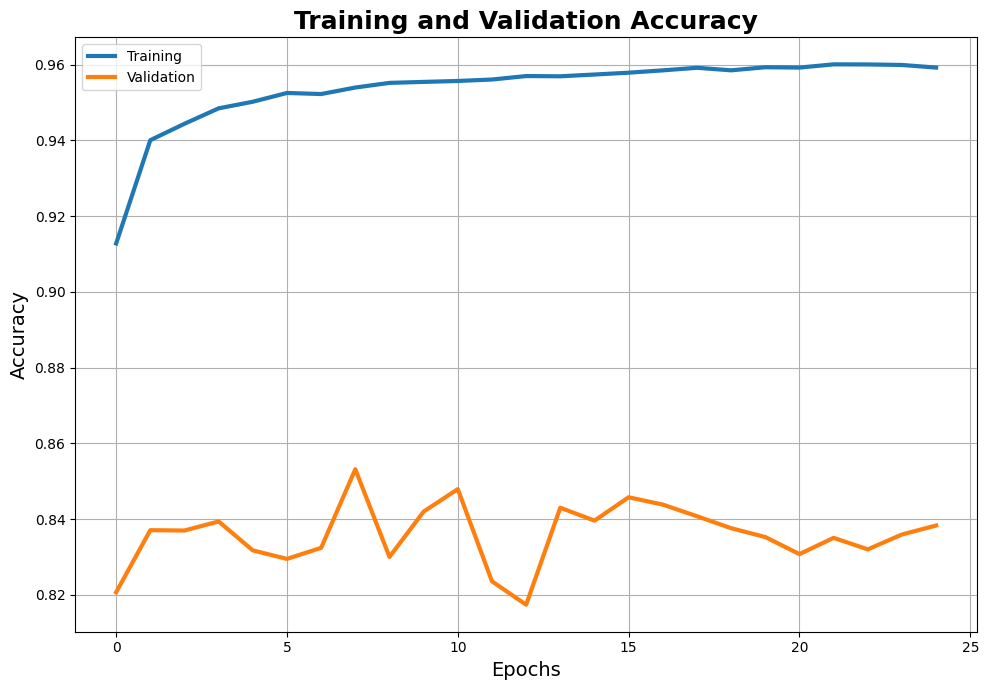

In [4]:
import pickle
import matplotlib.pyplot as plt

# Load the saved history
history = pickle.load(open("history.pkl", "rb"))

# Plotting the Accuracy Curve
plt.figure(figsize=(10,7))
plt.plot(history['accuracy'], linewidth=3)
plt.plot(history['val_accuracy'], linewidth=3)
plt.title("Training and Validation Accuracy", fontsize=18, fontweight='bold')
plt.xlabel("Epochs", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.legend(["Training", "Validation"])
plt.grid(True)
plt.tight_layout()

# Save the plot for GitHub README
plt.savefig("training_curves.png", dpi=300)
plt.show()